# ETF pairs / statistical arbitrage — walkthrough

Cointegration diagnostics, a single pair's spread z-score, and a walk-forward cointegration-gated portfolio. Mirrors `scripts/run_pairs.py`.

In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import pandas as pd

from quantbt.backtest import daily_returns, simulate
from quantbt.costs import CostModel
from quantbt.strategies.pairs import (
    hedge_ratio, cointegration_pvalue, half_life, pair_weights,
)

PAIRS = [('EWA','EWC'), ('GDX','GDXJ'), ('XLE','XOP'), ('SMH','SOXX'), ('SPY','IVV')]

## 1. Load prices

In [2]:
prices = pd.read_csv('data/etf_pairs.csv', index_col=0, parse_dates=True)
returns = daily_returns(prices)
prices.tail(3)

,EWA,EWC,GDX,GDXJ,IVV,SMH,SOXX,SPY,XLE,XOP
Date,,,,,,,,,,
2024-12-26,23.224203,39.609680,34.221458,42.569263,593.231689,250.151627,221.722000,591.218445,40.652622,124.609970
2024-12-27,22.975918,39.413692,34.012970,42.080524,586.809082,247.629471,219.847290,584.994934,40.647816,124.804153
2024-12-30,22.889973,39.286297,33.526505,41.366962,580.376587,243.901077,215.522537,578.319275,40.643013,126.833427


## 2. Cointegration diagnostics
For each a-priori pair: the Engle-Granger cointegration p-value (low = cointegrated) and the spread's mean-reversion half-life.

In [3]:
rows = []
for y, x in PAIRS:
    beta, alpha = hedge_ratio(prices[y], prices[x])
    spread = prices[y] - (beta * prices[x] + alpha)
    rows.append({'pair': f'{y}/{x}',
                 'coint_p': cointegration_pvalue(prices[y], prices[x]),
                 'half_life_days': half_life(spread)})
pd.DataFrame(rows).round(3)

,pair,coint_p,half_life_days
0,EWA/EWC,0.019,35.528
1,GDX/GDXJ,0.594,174.071
2,XLE/XOP,0.955,1266.766
3,SMH/SOXX,1.000,inf
4,SPY/IVV,0.497,9.595


## 3. A cointegrated pair: EWA / EWC
Australia vs Canada — two commodity-linked economies. The spread z-score mean-reverts; we enter at |z|>2 and exit near 0.

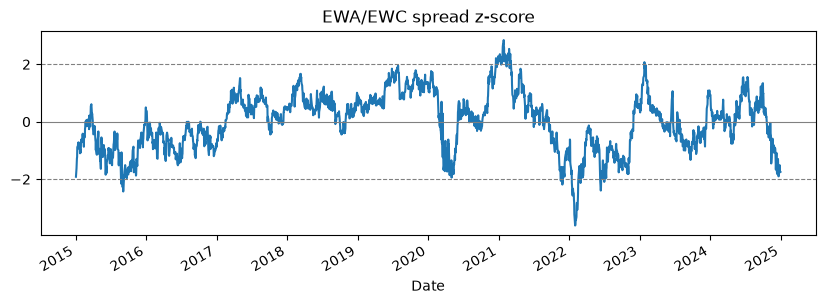

In [4]:
y, x = 'EWA', 'EWC'
beta, alpha = hedge_ratio(prices[y], prices[x])
spread = prices[y] - (beta * prices[x] + alpha)
z = (spread - spread.mean()) / spread.std()
ax = z.plot(figsize=(10, 3), title=f'{y}/{x} spread z-score')
for lvl, style in [(2, '--'), (-2, '--'), (0, '-')]:
    ax.axhline(lvl, color='grey', linestyle=style, linewidth=0.8)

## 4. Walk-forward, cointegration-gated portfolio
Each pair is traded only in windows where it tests as cointegrated in-sample; the pairs are combined into one equal-split book.

In [5]:
tickers = sorted({t for p in PAIRS for t in p})
weights_by_pair = {p: pair_weights(prices, *p) for p in PAIRS}
oos = pd.DatetimeIndex(sorted(set().union(*[w.index for w in weights_by_pair.values()])))
combined = pd.DataFrame(0.0, index=oos, columns=tickers)
for w in weights_by_pair.values():
    combined.loc[w.index, w.columns] = combined.loc[w.index, w.columns].add(
        w / len(PAIRS), fill_value=0.0)
result = simulate(returns.loc[combined.index], combined, CostModel())
pd.Series(result.summary()).round(3)

ann_return      0.002
ann_vol         0.011
sharpe          0.176
sortino         0.300
max_drawdown   -0.033
hit_rate        0.115
turnover        0.015
total_cost      0.019
dtype: float64

## Takeaway
Only EWA/EWC is robustly cointegrated. The gate keeps the book flat much of the time, giving a low-vol, low-return hedged portfolio with thin edge after costs. SPY/IVV is the cautionary case: nearly identical trackers whose spread is too tight to trade profitably once you pay to cross it. In liquid ETFs, most relative-value edge looks arbitraged away.